## Classification Evaluation Metrics:

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import precision_score, recall_score, f1_score, auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay, average_precision_score, precision_recall_curve

In [42]:
X, y = load_iris(return_X_y = True)

# only use two classes - because precision, recall, f1, roc_cureve, precision_recall_curve require only two classes
X = X[:100]
y = y[:100]

# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
# create pipeline for StandardScaler(); SVC
pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=42, probability=True)
)



In [57]:
# generate a list 
param_grid = [
    {'svc__C': [0.001,0.01,0.1, 1.0, 10.0, 100.0]}
]

# GridSearchCV
gs = GridSearchCV(estimator=pipe_svc,
                    param_grid = param_grid,
                    scoring='accuracy',
                    refit=True,
                    n_jobs=-1)

# fit the model
gs = gs.fit(X_train, y_train)

In [58]:
# 
best_param = gs.best_params_
best_score = gs.best_score_
print(f'Best paramaters: {best_param}')
print(f'Best score: {best_score}')

clf = gs.best_estimator_

Best paramaters: {'svc__C': 0.1}
Best score: 1.0


In [59]:
# make prediction
y_pred = clf.predict(X_test)

### **Confusion Matrix**

In [60]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[12,  0],
       [ 0,  8]])

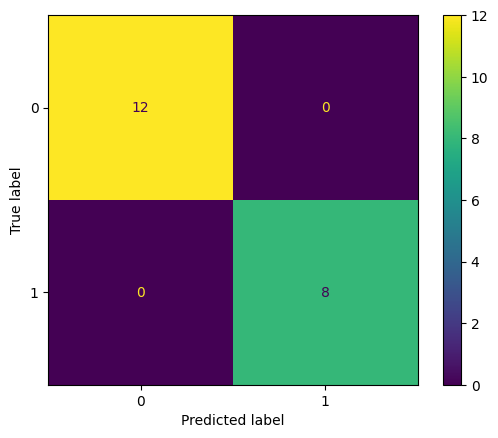

In [61]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

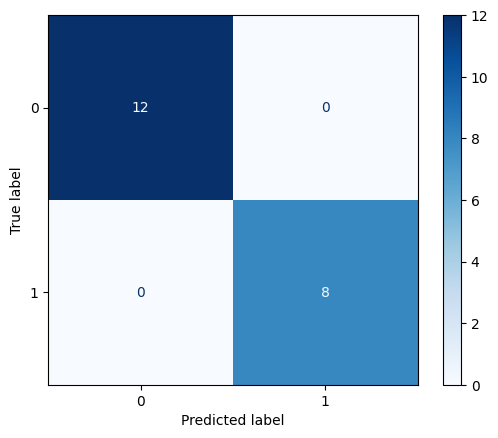

In [62]:
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test,
display_labels=[0, 1],
cmap='Blues')
plt.show()

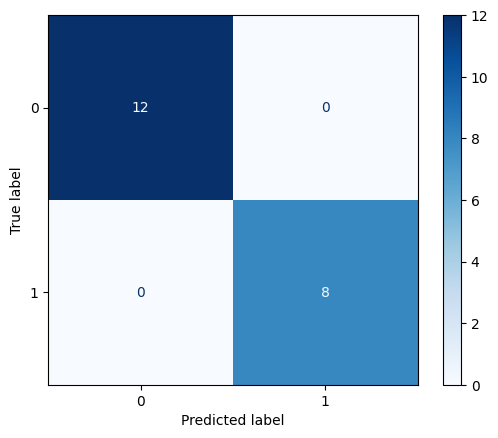

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()

### precision_score

In [64]:
precision_score(y_test, y_pred)

1.0

### recall_score

In [65]:
recall_score(y_test, y_pred)

1.0

### f1_score

In [66]:
f1_score(y_test, y_pred)

1.0

### roc_curve

In [75]:
# calculate the prediciton probability
pred_prob = clf.predict_proba(X_train)[:,1]

# calculate the fpr, tpr
fpr, tpr, threshold = roc_curve(y_train, pred_prob)

# calculate the auc score
roc_auc = auc(fpr, tpr)

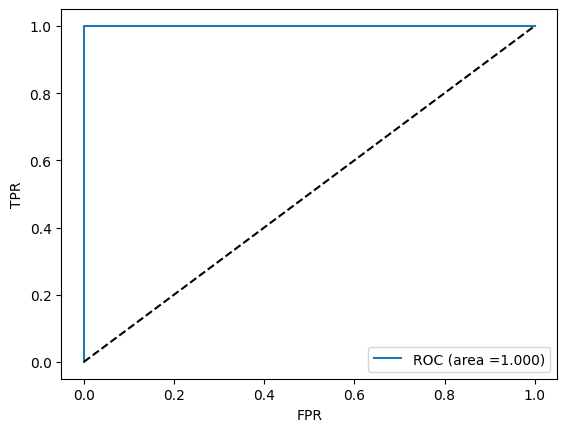

In [76]:
plt.plot(fpr, tpr, label=f'ROC (area ={roc_auc:.3f})')
plt.plot((0,1),(0,1), 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='best')
plt.show()

### average_precision_score; precision_recall_curve:

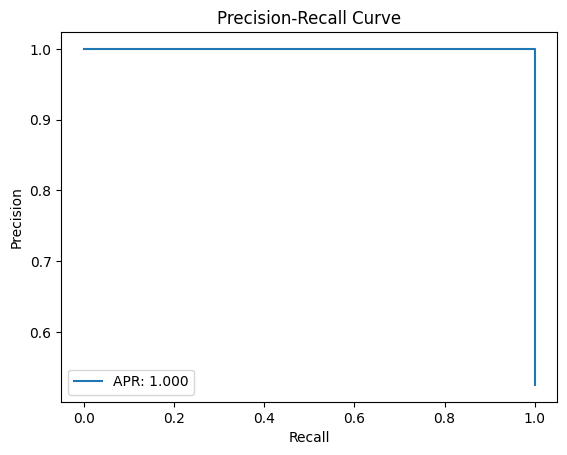

In [83]:
precision, recall, threshold = precision_recall_curve(y_train, pred_prob)
apr = average_precision_score(y_train, pred_prob)

plt.plot(recall, precision, label=f'APR: {apr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()